# Recomendation System for Moon NFT Exchange

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
listings = pd.read_csv("listings_df.csv")
presents = pd.read_csv("presents_df.csv")
transactions = pd.read_csv("transactions_df.csv")
listing_views = pd.read_csv("listings_view_df.csv")
users = pd.read_csv("users_df.csv")

In [3]:
listings.head()

,listing_id,present_id,seller_id,status_id,price,blockchain_tx_hash,created_at,updated_at
0,1,17,1,2,2.00,44076831bdfb9c10eea4609ac5d5efc0f7c8d8c32d2115...,2026-04-24 10:04:33.860784,2026-04-24 16:18:44.994410
1,2,22,16,1,10.00,NaN,2026-04-24 17:27:27.979196,2026-04-29 17:47:16.651635
2,3,28,17,2,1502.00,15e795d6ae3a855f9f7cc68d10abcff318e52244a016bb...,2026-04-24 18:00:12.182984,2026-04-27 06:27:20.077044
3,4,29,17,2,0.01,6131fa4789dbb73b4e9e405e303b61d380f0d99caa1725...,2026-04-24 18:01:52.627305,2026-04-27 06:29:50.453839
4,5,31,18,1,1000.00,NaN,2026-04-24 18:12:51.718141,2026-05-06 17:10:24.875302


In [4]:
presents.head()

,present_id,collection_id,model_id,background_id,symbol_id,present_num,image_url,generated_at,is_burned,description,is_visible,original_sender_id
0,2,1,29.0,17.0,481.0,1,generated_e59baadbf09b4917bd650259802ba622.png,2026-04-27 05:51:06.286198,0,NaN,1,2
1,3,5,323.0,32.0,394.0,1,generated_4185562bc2cb4ce29d9799af7785c79b.png,2026-04-24 09:59:46.440513,0,ура 2025,1,1
2,4,58,3904.0,43.0,45.0,1,generated_a7ed190fec4e4cb590a257329302fba6.png,2026-04-24 09:59:49.045898,0,хехе хитрый тыква,1,1
3,5,30,1958.0,67.0,670.0,1,generated_767b7f36261545118c696d87bdf72a9f.png,2026-04-24 18:22:35.635907,0,держи какаху #1,0,1
4,6,4,255.0,23.0,285.0,1,generated_96b6ed21e12f4bf5a1e888b0ba13a515.png,2026-04-27 05:51:09.289261,0,клубничка для сладенькой,1,1


In [5]:
transactions.head()

,transaction_id,buyer_id,seller_id,present_id,type_id,status_id,transaction_price,platform_fee,seller_received,blockchain_tx_hash,block_number,transaction_date,created_at
0,1,2,2,2,1,2,20.0,0.0,20.0,f83613549b38a4699edbd1ead9680a37a066d944b0e9cd...,8,2026-04-03 21:38:07.357852,2026-04-03 21:38:07.364932
1,2,1,1,3,1,2,1.0,0.0,1.0,8300bab21d92d3d8a598615586ada9abdd919538890a33...,6,2026-04-04 10:57:54.798153,2026-04-04 10:57:54.805484
2,3,1,1,4,1,2,1.0,0.0,1.0,2ce64b4f27a8a9a07fabee225e54be9c1e4a4798cd69c3...,7,2026-04-04 11:00:52.351498,2026-04-04 11:00:52.354701
3,4,5,1,5,1,2,1.0,0.0,1.0,5d53ff2f2189fc3b9f526f587a70797c07273578834eab...,8,2026-04-04 11:01:37.143155,2026-04-04 11:01:37.151241
4,5,2,1,6,1,2,1.0,0.0,1.0,577bf3fe57fdb00e5ac583e0878a1366fa5118d4cebab8...,9,2026-04-04 11:02:11.764946,2026-04-04 11:02:11.767329


In [6]:
listing_views.head()

,user_id,listing_id
0,13,5
1,13,7
2,1,13
3,5,13
4,13,132


In [7]:
users.head()

,user_id,role_id,user_tg_id,user_vk_id,tg_username,vk_username,tg_visibility,vk_visibility,username,profile_pic_url,wallet_address,wallet_private_key_encrypted,wallet_encryption_version,wallet_created_at,is_active,created_at,about_me
0,1,3,868752299,191144284.0,jdm_enjoyerr,vk_user_191144284,0,0,JDM_enjoyer1007,5a84dca61df34d13870831be1c884ac4.jpg,0xa5066c77aEDb0036C260f93f3a6290f7e519CE63,gAAAAABpxrQG6vG_Te4C00u25765vi7vj0OG6bVVSZAQ78...,1,2026-03-27 16:44:54.146793,1,2026-03-24 20:47:51.235998,VIP User
1,2,3,8052361559,NaN,cursed_supp,NaN,0,1,lyublyu_blondinok,419c6a879f0f434583783dc3f1dff70e.jpg,0xa0ef4982b0Fc6230c14F54becAffC4bD14F20E77,gAAAAABpxrQoxKdK9c1ikrEm-0EDB3SraLHdCiivRMwQK4...,1,2026-03-27 16:45:28.807612,1,2026-03-24 21:27:46.623502,ЛЮБЛЮ БЛОНДИНОКЛЮБЛЮ БЛОНДИНОКЛЮБЛЮ БЛОНДИНОКЛ...
2,3,2,8754635637,NaN,erik_tryhard_developer,NaN,0,1,zxcursed228,0526b317116c406f9a8a0d93189a4bcd.jpg,0x9ce92B819bA0273377621C3Df51F1EaA47f4C316,gAAAAABpxrQ7z7zbTKyyXXStKT-U2LaM8xNApXV5kPzQZd...,1,2026-03-27 16:45:47.782466,1,2026-03-24 21:28:11.783528,?From Ufa
3,4,1,1867061412,NaN,Alfamod_ik,NaN,1,1,Alfamod_ik,8a61e5a4a5d847ebaa7a8eb92549aede.jpg,0xcB3eBD5136691A03F7A2E3C72e43a4aD45aA107b,gAAAAABpxrRQEXFBCeFZzWWmf8_RIyt1iRuTTvTehbKrpx...,1,2026-03-27 16:46:08.749556,1,2026-03-26 13:55:27.763797,NaN
4,5,2,1451355915,NaN,d3v4stated,NaN,0,1,I_love_kami,d4f74708043347389feff1f1eac6dae7.jpg,0x2FE542861d326d449e9b16204Ad18b00C05e5834,gAAAAABpxrcSmjx0feUmjJjzsK8VD8Lj8Fl2zWF5n2F9bb...,1,2026-03-27 16:57:54.787858,1,2026-03-26 14:35:15.270269,ЛЮБЛЮ КАМИЛЛУ


In [8]:
print(listings.shape)
print(presents.shape)
print(transactions.shape)
print(listing_views.shape)
print(users.shape)

(436, 8)
(238, 12)
(566, 13)
(112, 2)
(20, 17)


In [9]:
user_listing_views = (
    listing_views
    .groupby(["user_id", "listing_id"])
    .size()
    .reset_index(name="views_count")
)

data = listings.merge(user_listing_views, on="listing_id", how="left")
data["views_count"] = data["views_count"].fillna(0).astype(int)

In [10]:
data.head()

,listing_id,present_id,seller_id,status_id,price,blockchain_tx_hash,created_at,updated_at,user_id,views_count
0,1,17,1,2,2.00,44076831bdfb9c10eea4609ac5d5efc0f7c8d8c32d2115...,2026-04-24 10:04:33.860784,2026-04-24 16:18:44.994410,NaN,0
1,2,22,16,1,10.00,NaN,2026-04-24 17:27:27.979196,2026-04-29 17:47:16.651635,NaN,0
2,3,28,17,2,1502.00,15e795d6ae3a855f9f7cc68d10abcff318e52244a016bb...,2026-04-24 18:00:12.182984,2026-04-27 06:27:20.077044,NaN,0
3,4,29,17,2,0.01,6131fa4789dbb73b4e9e405e303b61d380f0d99caa1725...,2026-04-24 18:01:52.627305,2026-04-27 06:29:50.453839,NaN,0
4,5,31,18,1,1000.00,NaN,2026-04-24 18:12:51.718141,2026-05-06 17:10:24.875302,13.0,1


In [11]:
data.shape

(473, 10)

In [12]:
data = data.merge(users, on="user_id", how="left")

In [13]:
data.head()

,listing_id,present_id,seller_id,status_id,price,blockchain_tx_hash,created_at_x,updated_at,user_id,views_count,...,vk_visibility,username,profile_pic_url,wallet_address,wallet_private_key_encrypted,wallet_encryption_version,wallet_created_at,is_active,created_at_y,about_me
0,1,17,1,2,2.00,44076831bdfb9c10eea4609ac5d5efc0f7c8d8c32d2115...,2026-04-24 10:04:33.860784,2026-04-24 16:18:44.994410,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,22,16,1,10.00,NaN,2026-04-24 17:27:27.979196,2026-04-29 17:47:16.651635,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,28,17,2,1502.00,15e795d6ae3a855f9f7cc68d10abcff318e52244a016bb...,2026-04-24 18:00:12.182984,2026-04-27 06:27:20.077044,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,29,17,2,0.01,6131fa4789dbb73b4e9e405e303b61d380f0d99caa1725...,2026-04-24 18:01:52.627305,2026-04-27 06:29:50.453839,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,31,18,1,1000.00,NaN,2026-04-24 18:12:51.718141,2026-05-06 17:10:24.875302,13.0,1,...,1.0,ЗОЛОТОЙМАГНАТ,6349a6a90fee4b079115eade903aabaa.jpg,0xCce871D778b00E014cC13B1094837a5149aC74d9,gAAAAABpyqdUYyzzoRGJFn-Gj8DTcVmmy5tdvEijG5w-oS...,1.0,2026-03-30 16:39:48.865225,1.0,2026-03-30 16:39:48.830278,ЗОЛОТО ЗОЛОТО ЗОЛОТО ЗОЛОТО ЗОЛОТО ЗОЛОТО ЗОЛОТО


In [14]:
data.shape

(473, 26)

In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   listing_id                    473 non-null    int64  
 1   present_id                    473 non-null    int64  
 2   seller_id                     473 non-null    int64  
 3   status_id                     473 non-null    int64  
 4   price                         473 non-null    float64
 5   blockchain_tx_hash            112 non-null    str    
 6   created_at_x                  473 non-null    str    
 7   updated_at                    473 non-null    str    
 8   user_id                       112 non-null    float64
 9   views_count                   473 non-null    int64  
 10  role_id                       112 non-null    float64
 11  user_tg_id                    112 non-null    float64
 12  user_vk_id                    12 non-null     float64
 13  tg_username     

In [16]:
data = data.drop(columns=["blockchain_tx_hash", 'created_at_y', 'updated_at', 'created_at_x', 'role_id', 'user_tg_id', 'user_vk_id', 'username', 'profile_pic_url', 'wallet_address', 'wallet_private_key_encrypted', 'wallet_encryption_version', 'wallet_created_at', 'is_active', 'about_me', 'tg_username', 'vk_username', 'tg_visibility', 'vk_visibility'])

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   listing_id   473 non-null    int64  
 1   present_id   473 non-null    int64  
 2   seller_id    473 non-null    int64  
 3   status_id    473 non-null    int64  
 4   price        473 non-null    float64
 5   user_id      112 non-null    float64
 6   views_count  473 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 26.0 KB


In [18]:
data = data.merge(presents, on="present_id", how="left")

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          473 non-null    int64  
 1   present_id          473 non-null    int64  
 2   seller_id           473 non-null    int64  
 3   status_id           473 non-null    int64  
 4   price               473 non-null    float64
 5   user_id             112 non-null    float64
 6   views_count         473 non-null    int64  
 7   collection_id       473 non-null    int64  
 8   model_id            473 non-null    float64
 9   background_id       473 non-null    float64
 10  symbol_id           473 non-null    float64
 11  present_num         473 non-null    int64  
 12  image_url           473 non-null    str    
 13  generated_at        473 non-null    str    
 14  is_burned           473 non-null    int64  
 15  description         154 non-null    str    
 16  is_visible         

In [20]:
data = data.drop(columns=['image_url', 'generated_at', 'is_burned', 'description', 'is_visible', 'original_sender_id'])

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   listing_id     473 non-null    int64  
 1   present_id     473 non-null    int64  
 2   seller_id      473 non-null    int64  
 3   status_id      473 non-null    int64  
 4   price          473 non-null    float64
 5   user_id        112 non-null    float64
 6   views_count    473 non-null    int64  
 7   collection_id  473 non-null    int64  
 8   model_id       473 non-null    float64
 9   background_id  473 non-null    float64
 10  symbol_id      473 non-null    float64
 11  present_num    473 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 44.5 KB


In [22]:
data = data[data['status_id'] == 1]
data = data.drop(columns=['status_id'])

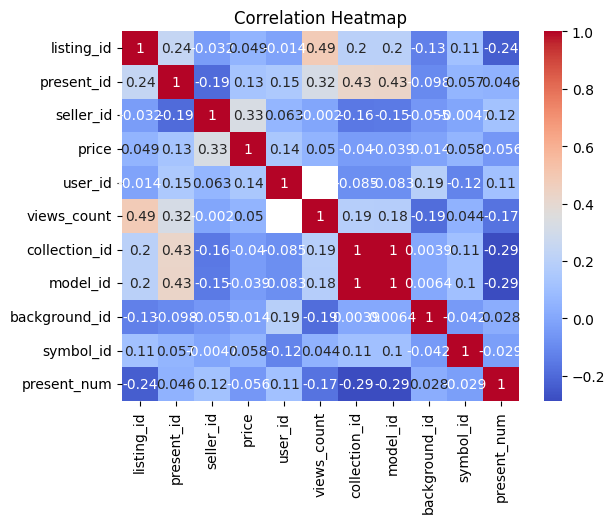

<Figure size 1800x1400 with 0 Axes>

In [23]:
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.figure(figsize=(18, 14))
plt.show()

In [24]:
users_pivot = data.pivot_table(index='user_id', columns='listing_id', values='views_count', fill_value=0)
users_pivot.head()

listing_id,5,7,13,132,149,153,160,173,189,203,...,422,423,424,426,427,428,429,431,432,433
user_id,,,,,,,,,,,,,,,,,,,,,
1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
13.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


In [25]:
def samelots(lot):
    users_vote_lot = users_pivot[lot]
    similar_lots = users_pivot.corrwith(users_vote_lot)
    similar_lots = pd.DataFrame(similar_lots, columns=['correlation'])
    print(similar_lots)
    df = similar_lots.sort_values(by='correlation', ascending=False).head(10)
    print(df)
    df_sort = df[df['correlation'] > 0.8]
    return df_sort

In [29]:
samelots(433)

            correlation
listing_id             
5             -0.316228
7             -0.316228
13             0.250000
132           -0.316228
149           -0.316228
...                 ...
428            0.707107
429            0.500000
431            0.000000
432           -0.500000
433            1.000000

[71 rows x 1 columns]
            correlation
listing_id             
433            1.000000
428            0.707107
376            0.632456
429            0.500000
426            0.500000
13             0.250000
418            0.250000
408            0.250000
398            0.250000
431            0.000000


,correlation
listing_id,
433,1.0
